In [1]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import progressbar

%matplotlib inline
auto_plot_style()

In [2]:
def summarize(evt):
    qtot = len(evt)
    qmax = evt.groupby("sensor_id").count().values.max()
    return pd.DataFrame(dict(qtot=qtot, qmax=qmax), index=[0])

In [24]:
path      = Path("/home/gonzalo/data/COLINA/mc/d_sipms/")
filenames = sorted(path.glob("*.h5"))

data = []
for filename in progressbar(filenames):
    dist = int(filename.stem.split("_")[1])
    df   = pd.read_hdf(filename, "/MC/sensor_hits")
    df   = df.loc[df.sensor_id < 100]
    df   = (df.groupby("event")
              .apply(summarize, include_groups=False)
              .reset_index(level=1, drop=True)
              .reset_index()
           )
    data.append(df.assign(dist=dist))

data = pd.concat(data, ignore_index=True)

Item 17 of 17 | 2.85 s/item | ETA 0.0 min | Ellapsed 0.8 min


In [25]:
data

,event,qtot,qmax,dist
0,0,328,22,2
1,1,351,32,2
2,2,368,31,2
3,3,343,18,2
4,4,238,25,2
...,...,...,...,...
169961,9995,162,5,30
169962,9996,153,6,30
169963,9997,119,5,30
169964,9998,139,5,30


In [26]:
data.qtot.describe()

count    169966.000000
mean        241.249126
std          70.010555
min          15.000000
25%         189.000000
50%         236.000000
75%         293.000000
max         458.000000
Name: qtot, dtype: float64

In [27]:
qtotbins = np.linspace(0, 600, 101)
qmaxbins = np.arange(60)

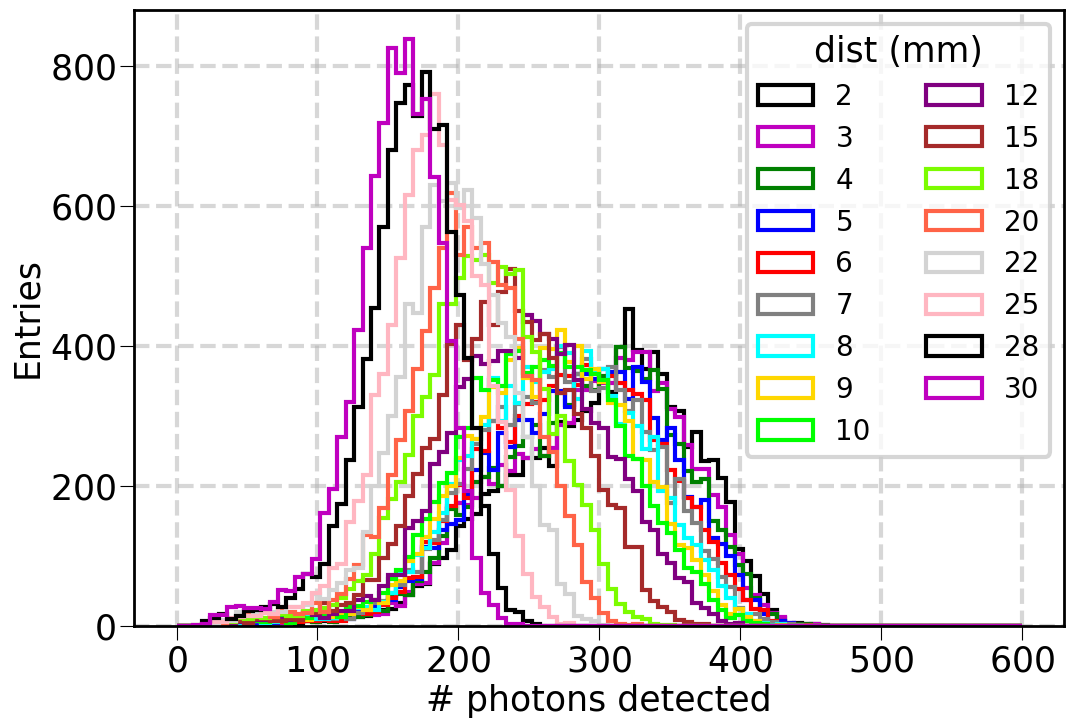

In [28]:
plt.figure(figsize=(12, 8))
for d, df in data.groupby("dist"):
    plt.hist(df.qtot, qtotbins, histtype="step", label=str(d))
plt.legend(ncol=2, fontsize=20, title="dist (mm)")
plt.xlabel("# photons detected")
plt.ylabel("Entries")
plt.grid()

In [9]:
dftot = data.groupby("dist").qtot.agg("mean std count".split()).add_prefix("qtot_")
dfmax = data.groupby("dist").qmax.agg("mean std count".split()).add_prefix("qmax_")
df    = pd.concat([dftot, dfmax], axis=1).reset_index()
df

,dist,qtot_mean,qtot_std,qtot_count,qmax_mean,qmax_std,qmax_count
0,2,298.522352,63.612318,9999,25.981998,4.546582,9999
1,3,292.172635,64.020665,9998,23.341868,4.119398,9998
2,4,288.494299,63.579873,9998,21.163333,3.796966,9998
3,5,282.417634,63.073337,9992,19.363391,3.399905,9992
4,6,278.567700,61.376190,10000,17.839400,3.107245,10000
5,7,272.897269,61.224892,9997,16.438932,2.899269,9997
6,8,268.136255,59.811694,9996,15.380352,2.679997,9996
7,9,263.530053,58.430962,9999,14.392639,2.553851,9999
8,10,258.036807,57.833579,9998,13.461092,2.354209,9998
9,12,248.617962,54.978448,9999,12.074807,2.126478,9999


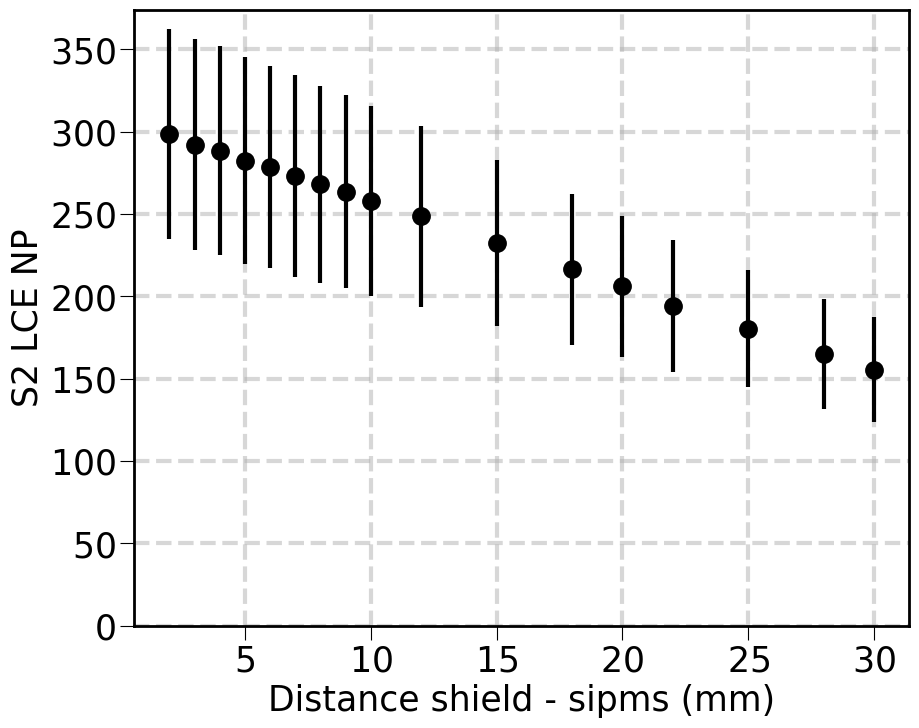

In [16]:
plt.errorbar(df.dist, df.qtot_mean, df.qtot_std, fmt=".k")
plt.xlabel("Distance shield - sipms (mm)")
plt.ylabel("S2 LCE NP")
plt.ylim(0)
plt.grid()

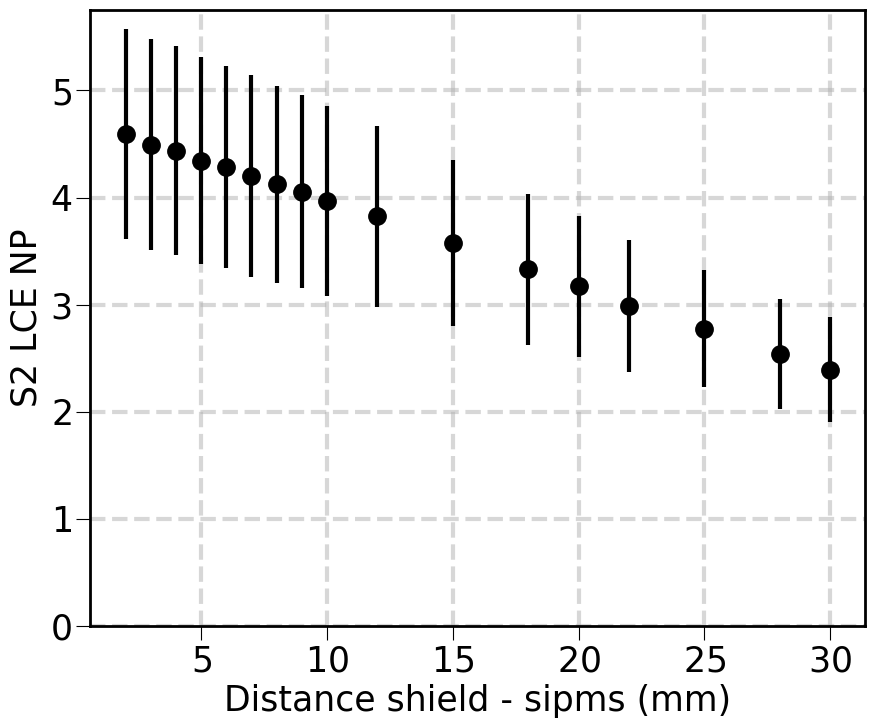

In [14]:
plt.errorbar(df.dist, df.qtot_mean*100/6500, df.qtot_std*100/6500, fmt=".k")
plt.xlabel("Distance shield - sipms (mm)")
plt.ylabel("S2 LCE NP")
plt.ylim(0)
plt.grid()

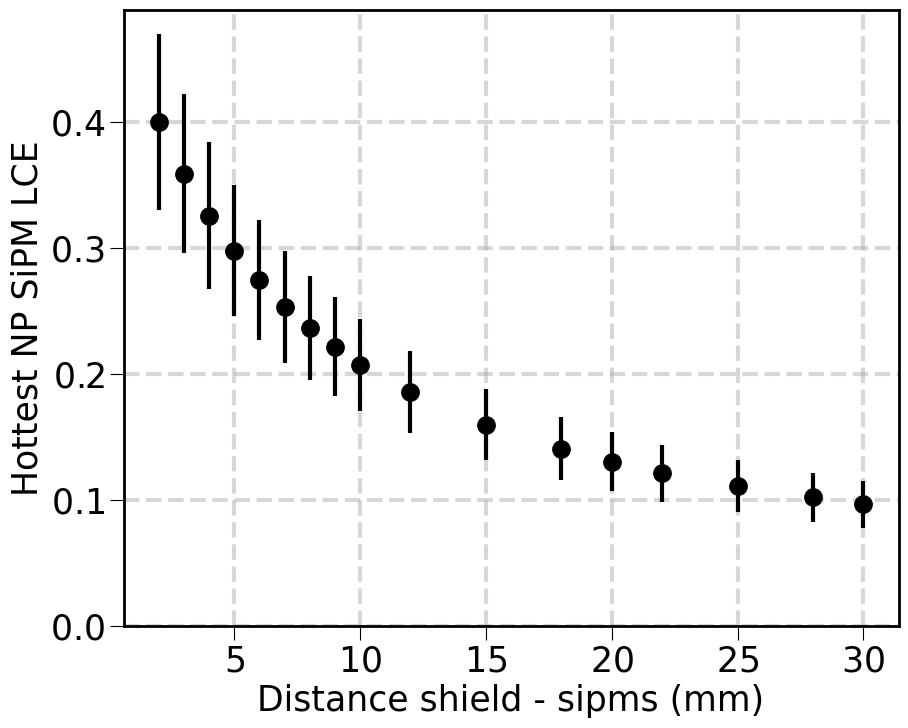

In [15]:
plt.errorbar(df.dist, df.qmax_mean*100/6500, df.qmax_std*100/6500, fmt=".k")
plt.xlabel("Distance shield - sipms (mm)")
plt.ylabel("Hottest NP SiPM LCE")
plt.ylim(0)
plt.grid()